# Análisis y predicción del desempeño de campañas de marketing digital

## Contexto del proyecto

Las campañas de marketing digital requieren una planificación previa que permita estimar su impacto antes de invertir presupuesto.
Decisiones como cuánto gastar, en qué mes lanzar la campaña o a qué rango etario apuntar influyen directamente en el alcance y la rentabilidad.

El objetivo de este proyecto es:
- Analizar el desempeño histórico de campañas de marketing.
- Evaluar su eficiencia mediante métricas como ROI y tasas de conversión.
- Identificar patrones de alto rendimiento.
- Construir un modelo predictivo que permita estimar las impresiones esperadas antes de lanzar una campaña.


## Objetivos

- Realizar un análisis exploratorio del desempeño de campañas de marketing.
- Evaluar la eficiencia económica mediante ROI y métricas del funnel.
- Analizar patrones de comportamiento mediante técnicas de clustering.
- Entrenar modelos de machine learning supervisado para predecir impresiones.
- Simular un escenario real donde un cliente pueda estimar resultados antes de lanzar una campaña.


## Carga de datos

Se utiliza un dataset histórico de campañas de marketing digital que contiene información sobre costos, impresiones, conversiones y revenue.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel('../Data/Marketing_Campaign_Data.xlsx')

# EDA

## El análisis exploratorio tiene como objetivo:

 * comprender la distribución de las métricas del funnel, identificar relaciones entre plataformas, regiones y resultados, y evaluar qué métricas son estables o volátiles para su uso en modelos predictivos.

### 1. Estructura y tipos de datos

Se revisa la estructura general del dataset, tipos de variables y presencia de valores faltantes.

In [51]:
df.head(5)

,Date,CampaignID,CampaignName,Platform,TargetAudience,Impressions,Clicks,Leads,Applications,Enrollments,...,ctr,lead_rate,application_rate,enrollment_rate,age_numeric,cluster,is_cluster_0,month,month_sin,month_cos
0,2024-01-01,AD004,Hackathon,YouTube,17–21 Age,285708,16956,4087,2547,1148,...,0.059347,0.241036,0.623195,0.450726,19.0,2,0,1,0.5,0.866025
1,2024-01-02,AD004,Hackathon,YouTube,17–21 Age,140449,10082,1815,951,565,...,0.071784,0.180024,0.523967,0.594111,19.0,2,0,1,0.5,0.866025
2,2024-01-03,AD004,Hackathon,YouTube,17–21 Age,140958,7474,1169,683,343,...,0.053023,0.156409,0.584260,0.502196,19.0,2,0,1,0.5,0.866025
3,2024-01-04,AD004,Hackathon,YouTube,22–27 Age,257823,16841,3179,1584,698,...,0.065320,0.188766,0.498270,0.440657,24.5,1,0,1,0.5,0.866025
4,2024-01-05,AD004,Hackathon,YouTube,25–35 Age,98595,7293,1340,854,368,...,0.073969,0.183738,0.637313,0.430913,30.0,1,0,1,0.5,0.866025


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 763 entries, 0 to 762
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            763 non-null    datetime64[ns]
 1   CampaignID      763 non-null    object        
 2   CampaignName    763 non-null    object        
 3   Platform        763 non-null    object        
 4   TargetAudience  763 non-null    object        
 5   Impressions     763 non-null    int64         
 6   Clicks          763 non-null    int64         
 7   Leads           763 non-null    int64         
 8   Applications    763 non-null    int64         
 9   Enrollments     763 non-null    int64         
 10  Cost (₹)        763 non-null    float64       
 11  Revenue (₹)     763 non-null    float64       
 12  Region          763 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(5)
memory usage: 77.6+ KB


In [10]:
df.describe()

,Date,Impressions,Clicks,Leads,Applications,Enrollments,Cost (₹),Revenue (₹)
count,763,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,7.630000e+02
mean,2024-11-22 09:28:04.403669760,169276.787680,9355.716907,1862.757536,1027.019659,514.173001,119853.382949,2.838090e+06
min,2024-01-01 00:00:00,50267.000000,1674.000000,327.000000,159.000000,73.000000,22689.880000,3.646384e+05
25%,2024-06-08 12:00:00,106156.000000,5448.000000,1085.500000,589.000000,291.500000,67979.100000,1.510477e+06
50%,2024-11-15 00:00:00,166847.000000,8435.000000,1684.000000,909.000000,451.000000,109850.410000,2.405412e+06
75%,2025-05-12 12:00:00,232192.500000,12587.500000,2496.000000,1365.000000,682.000000,160215.240000,3.783393e+06
max,2025-10-31 00:00:00,299910.000000,23654.000000,5219.000000,3112.000000,1664.000000,288391.330000,1.157730e+07
std,NaN,73046.934246,4949.433462,1007.799358,574.587368,294.810151,62180.851193,1.800129e+06


### 2. Análisis de variables categóricas

Se analizan las principales variables categóricas para entender la distribución de campañas, audiencias y plataformas.

In [7]:
df[['CampaignID','CampaignName','Platform','TargetAudience','Region']].nunique()

CampaignID        5
CampaignName      5
Platform          5
TargetAudience    4
Region            5
dtype: int64

In [52]:
for col in ['Region','CampaignName','Platform','TargetAudience']:
    display(f'Los valores de {col} :{df[col].unique()}')
   


"Los valores de Region :['West India' 'North India' 'East India' 'Pan India' 'South India']"

"Los valores de CampaignName :['Hackathon' 'UG Admission' 'Semester Exchange Program' 'Placements'\n 'MBA Admission']"

"Los valores de Platform :['YouTube' 'Google Ads' 'Instagram' 'LinkedIn' 'Facebook']"

"Los valores de TargetAudience :['17–21 Age' '22–27 Age' '25–35 Age' '21–35 Age']"

### 3. Análisis de variables numéricas

Se exploran las variables numéricas clave para entender rangos, dispersión y valores extremos.

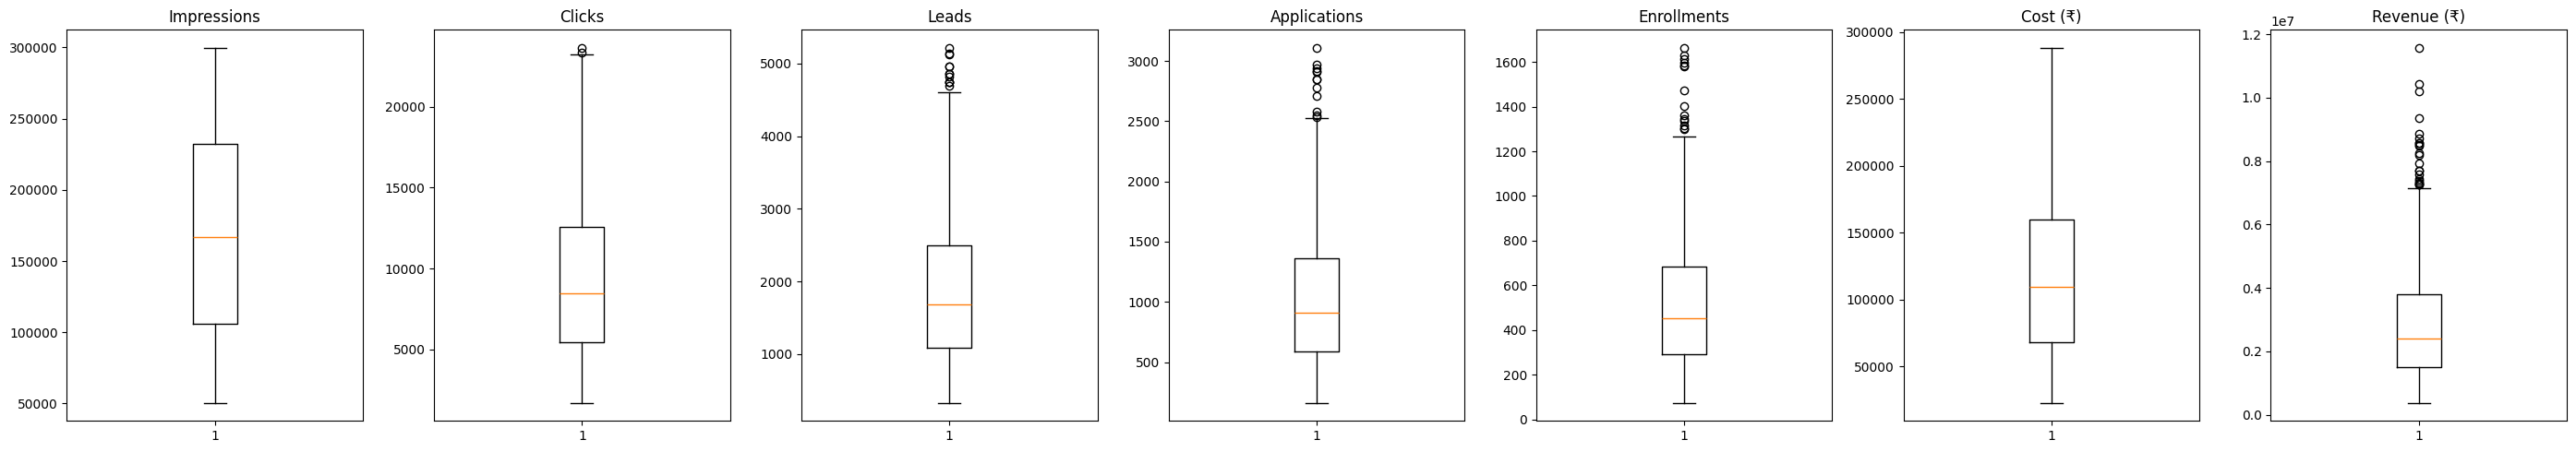

In [13]:
import matplotlib.pyplot as plt

cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(1, len(cols), figsize=(4*len(cols), 5))

for ax, col in zip(axes, cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()


En este grafico podemos identificar que las variables con mayor numero de outliers son **Leads , Applications , Enrollments y Revenue**

### Distribución de métricas del funnel de marketing
- La distribución de impresiones muestra una alta concentración en valores bajos y medios, con una disminución gradual en la frecuencia a medida que aumentan las impresiones. No se observan outliers extremos, lo que sugiere que las campañas presentan rangos de exposición relativamente homogéneos. Este comportamiento indica que las impresiones son una variable más estable y potencialmente controlable en comparación con métricas posteriores del funnel.

- Tambien apreciamos que desde el grafico de "Click" en adelante los volumenes comienzan a disminuir significativamente, pero dentro de lo esperable dentro de metricas asociadas a marketing digital.


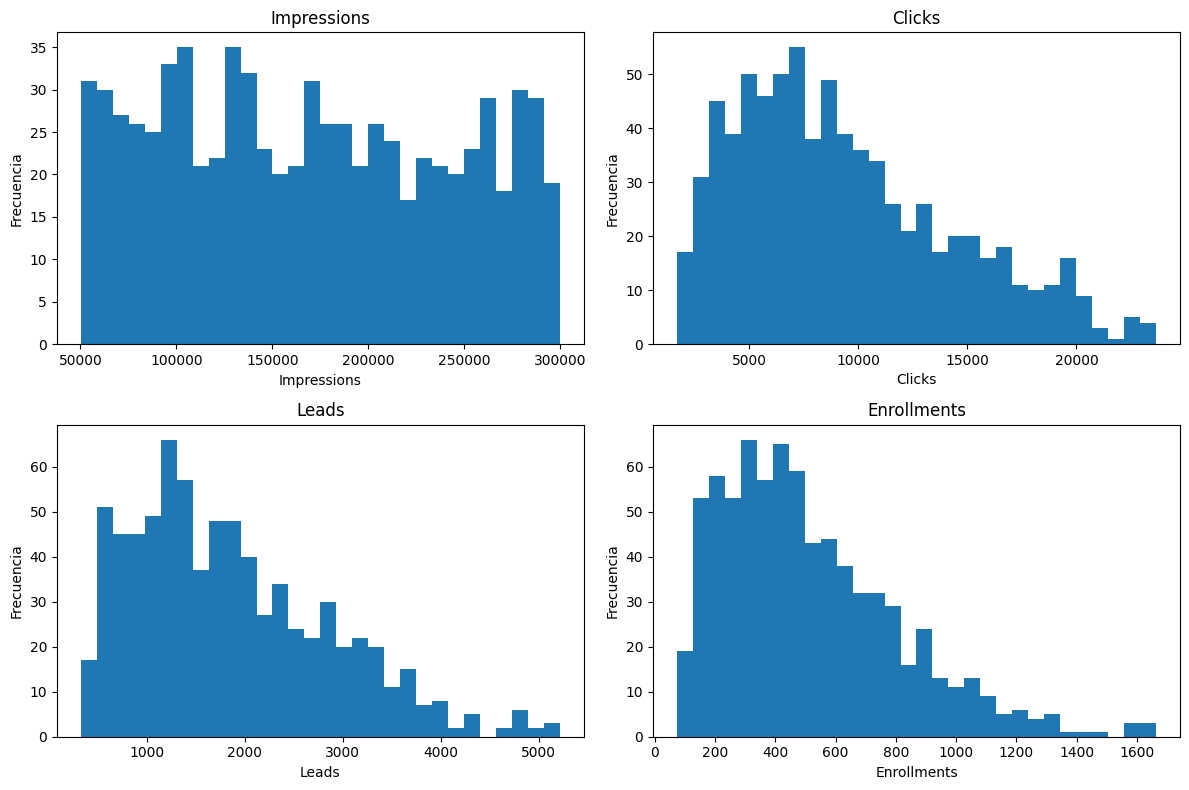

In [ ]:
import matplotlib.pyplot as plt

variables = ['Impressions', 'Clicks', 'Leads', 'Enrollments']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten() 

for ax, col in zip(axes, variables):
    ax.hist(df[col], bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


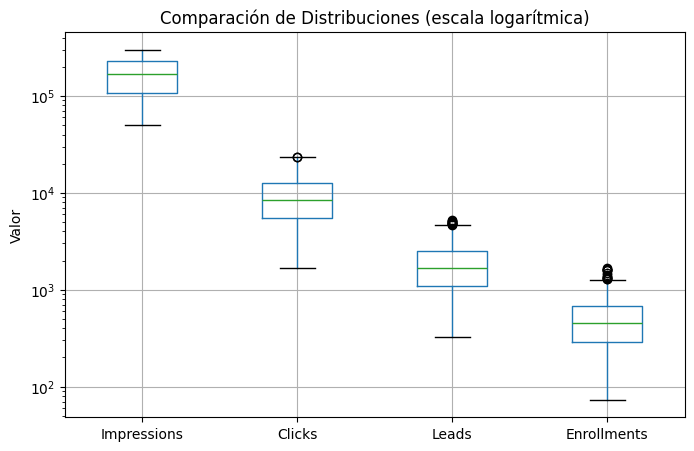

In [50]:
plt.figure(figsize=(8,5))
df[['Impressions', 'Clicks', 'Leads', 'Enrollments']].boxplot()
plt.yscale('log') 
plt.title('Comparación de Distribuciones (escala logarítmica)')
plt.ylabel('Valor')
plt.show()


En este grafico podemos visualizar de mejor manera que la variable **Enrollments** presenta un rango de valores considerablemente menor en comparación con **Impressions**, lo cual es consistente con su posición final dentro del embudo de conversión. Aunque la frecuencia de ciertos valores puede ser elevada, el número máximo de inscripciones es bajo en términos absolutos, reflejando la pérdida progresiva de usuarios a lo largo del proceso.

## Evaluación de eficiencia económica (ROI)


In [14]:
df['ROI'] = (df['Revenue (₹)'] - df['Cost (₹)']) / df['Cost (₹)']

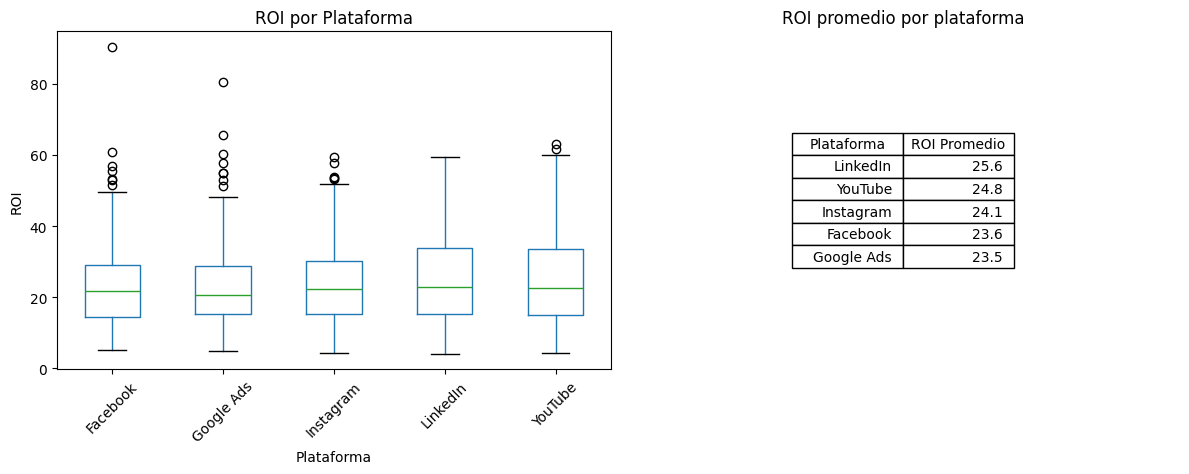

In [ ]:
import matplotlib.pyplot as plt


mean_roi = df.groupby('Platform')['ROI'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12,5))


df.boxplot(column='ROI', by='Platform', ax=axes[0], grid=False)
axes[0].set_title('ROI por Plataforma')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('ROI')
axes[0].tick_params(axis='x', rotation=45)


axes[1].axis('off')
axes[1].set_title('ROI promedio por plataforma')
table_data = [[plat, f"{val:.1f}"] for plat, val in mean_roi.items()]
table = axes[1].table(
    cellText=table_data,
    colLabels=['Plataforma', 'ROI Promedio'],
    loc='center',
    colWidths=[0.2, 0.2]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.suptitle('')
plt.tight_layout()
plt.show()


## Evaluación de eficiencia operativa (tasa de conversión)


### Evaluacion de tasa de converison

La tasa de conversión mide la proporción de usuarios que, habiendo hecho clic en una campaña, completan la inscripción. Se expresa como un valor decimal que puede interpretarse como porcentaje. Esta métrica permite evaluar la eficiencia del proceso de conversión independientemente del volumen de tráfico.

In [16]:
df['conversion_rate'] = df['Enrollments'] / df['Clicks']

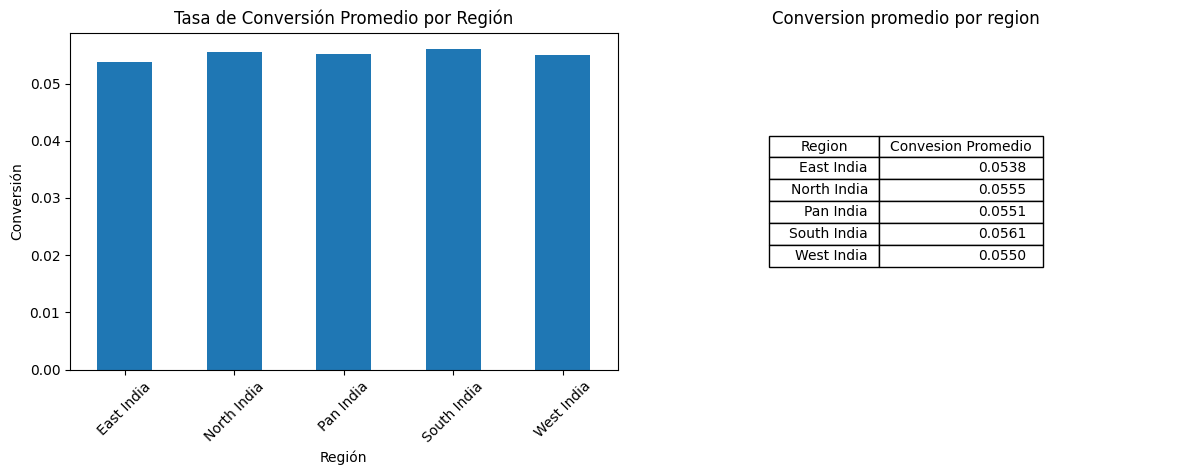

In [17]:
import matplotlib.pyplot as plt

# Cálculo de medias
region_conv = df.groupby('Region')['conversion_rate'].mean()


fig, axes = plt.subplots(1, 2, figsize=(12,5))


region_conv.plot(kind='bar', ax=axes[0])
axes[0].set_title('Tasa de Conversión Promedio por Región')
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Conversión')
axes[0].tick_params(axis='x', rotation=45)

# ---- TABLA ----
axes[1].axis('off')
axes[1].set_title('Conversion promedio por region')
table_data = [[plat, f"{val:.4f}"] for plat, val in region_conv.items()]
table = axes[1].table(
    cellText=table_data,
    colLabels=['Region', 'Convesion Promedio'],
    loc='center',
    colWidths=[0.2, 0.3]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.suptitle('')
plt.tight_layout()
plt.show()


# Evaluacion de Revenue y Cost

## Análisis temporal de ingresos, costos y ROI

Se analiza la evolución mensual del gasto, los ingresos y la rentabilidad para identificar patrones estacionales y períodos más eficientes.


In [53]:
df_time_month = df.set_index('Date').resample('ME')[['Revenue (₹)', 'Cost (₹)']].sum()

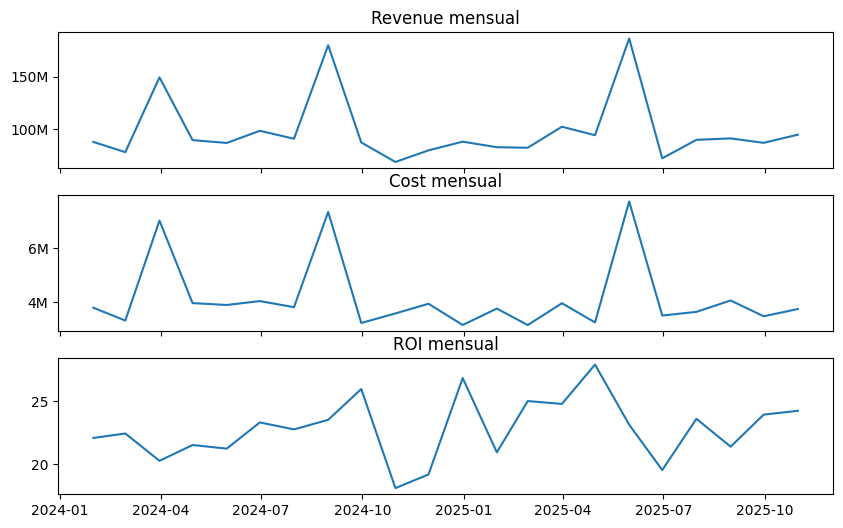

In [54]:
import matplotlib.ticker as mtick
df_time_month['ROI'] = (
    df_time_month['Revenue (₹)'] - df_time_month['Cost (₹)']
) / df_time_month['Cost (₹)']

fig, axes = plt.subplots(3, 1, figsize=(10,6), sharex=True)

axes[0].plot(df_time_month.index, df_time_month['Revenue (₹)'])
axes[0].set_title('Revenue mensual')
axes[0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

axes[1].plot(df_time_month.index, df_time_month['Cost (₹)'])
axes[1].set_title('Cost mensual')
axes[1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

axes[2].plot(df_time_month.index, df_time_month['ROI'])
axes[2].set_title('ROI mensual')

plt.show()


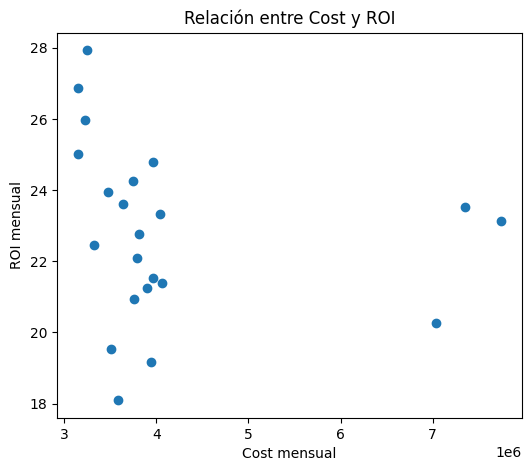

In [20]:
plt.figure(figsize=(6,5))
plt.scatter(df_time_month['Cost (₹)'], df_time_month['ROI'])
plt.xlabel('Cost mensual')
plt.ylabel('ROI mensual')
plt.title('Relación entre Cost y ROI')
plt.show()


Se observa que, si bien los meses con mayor gasto publicitario tienden a generar mayores ingresos, esto no implica necesariamente un ROI más alto. En algunos períodos, meses con un gasto menor presentan un ROI superior, lo que indica una mayor eficiencia en la inversión. Esto evidencia que un mayor volumen de inversión no garantiza una mayor rentabilidad relativa, y refuerza la importancia de evaluar las campañas en términos de eficiencia y no solo de ingresos absolutos

## Análisis del funnel de conversión

Para entender dónde se producen las principales pérdidas de usuarios, se construye el funnel completo desde impresiones hasta inscripciones.


## Creacion de nuevas features

In [21]:
df['ctr'] = df['Clicks'] / df['Impressions']                # Click Through Rate
df['lead_rate'] = df['Leads'] / df['Clicks']                # Click → Lead
df['application_rate'] = df['Applications'] / df['Leads']  # Lead → Application
df['enrollment_rate'] = df['Enrollments'] / df['Applications']  # Application → Enrollment

## Funnel promedio (visión global)

**¿Por qué se analiza el funnel promedio?**

* El funnel promedio responde a esta pregunta:

* En una campaña “típica”, ¿cuántas personas llegan a cada etapa?

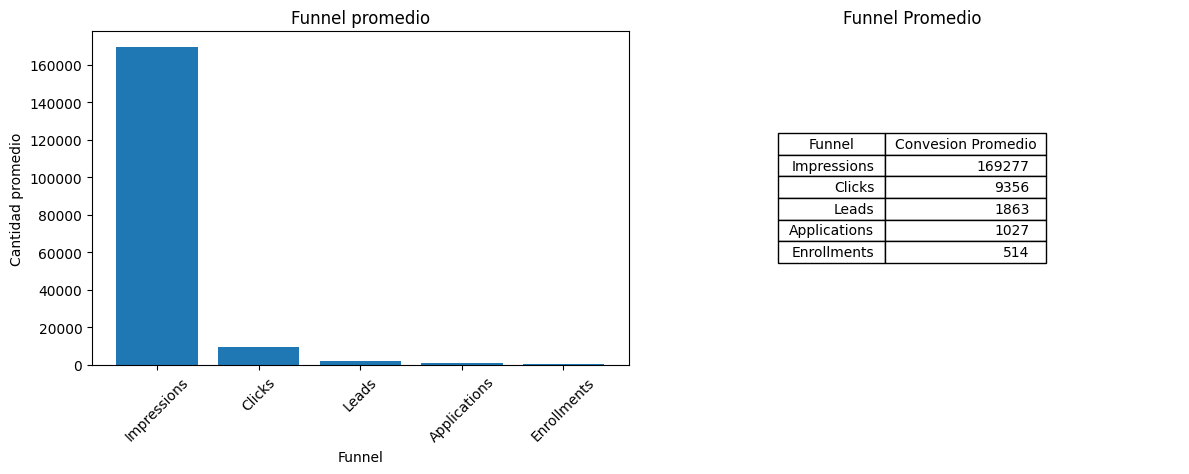

In [22]:
import matplotlib.pyplot as plt

# Cálculo de medias
funnel_avg = df[[
    'Impressions',
    'Clicks',
    'Leads',
    'Applications',
    'Enrollments'
]].mean()


fig, axes = plt.subplots(1, 2, figsize=(12,5))

# realizar grafico bar en el axes 0, de esta manera plt.bar(funnel_avg.index, funnel_avg.values)
axes[0].bar(funnel_avg.index, funnel_avg.values)
axes[0].set_title('Funnel promedio')
axes[0].set_ylabel('Cantidad promedio')
axes[0].set_xlabel('Funnel')
axes[0].tick_params(axis='x', rotation=45)

# ---- TABLA ----
axes[1].axis('off')
axes[1].set_title('Funnel Promedio')
table_data = [[plat, f"{val:.0f}"] for plat, val in funnel_avg.items()]
table = axes[1].table(
    cellText=table_data,
    colLabels=['Funnel', 'Convesion Promedio'],
    loc='center',
    colWidths=[0.2, 0.3]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.suptitle('')
plt.tight_layout()
plt.show()


## Analizar tasas promedio

## Tasa promedio del funnel

**¿Por qué se analizan las tasas promedio del funnel?**

Las tasas promedio responden a otra pregunta:

¿Qué tan eficiente es cada transición del proceso?

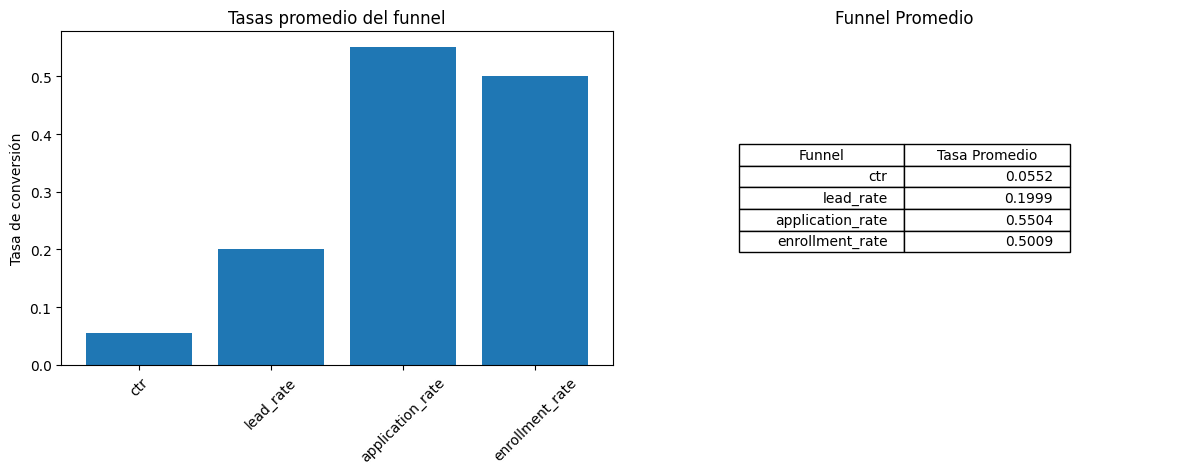

In [23]:
import matplotlib.pyplot as plt

# Cálculo de medias
rates_avg = df[[
    'ctr',
    'lead_rate',
    'application_rate',
    'enrollment_rate'
]].mean()


fig, axes = plt.subplots(1, 2, figsize=(12,5))

# realizar grafico bar en el axes 0, de esta manera plt.bar(funnel_avg.index, funnel_avg.values)
axes[0].bar(rates_avg.index, rates_avg.values)
axes[0].set_title('Tasas promedio del funnel')
axes[0].set_ylabel('Tasa de conversión')
axes[0].tick_params(axis='x', rotation=45)

# ---- TABLA ----
axes[1].axis('off')
axes[1].set_title('Funnel Promedio')
table_data = [[plat, f"{val:.4f}"] for plat, val in rates_avg.items()]
table = axes[1].table(
    cellText=table_data,
    colLabels=['Funnel', 'Tasa Promedio'],
    loc='center',
    colWidths=[0.3, 0.3]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.suptitle('')
plt.tight_layout()
plt.show()


El análisis de las tasas de conversión muestra que el principal cuello de botella del proceso se encuentra en la etapa de Impressions a Clicks, con un CTR promedio del 5.5%. Una vez superada esta etapa, las tasas de conversión aumentan significativamente, lo que sugiere que el proceso posterior es eficiente y que las principales oportunidades de mejora se concentran en la captación inicial.

## Segmentación exploratoria de campañas (Clustering)

Se utiliza clustering como una herramienta exploratoria para identificar patrones de desempeño, no como una segmentación definitiva.


In [24]:
def age_range_to_number(age_range):
    # limpiar texto
    clean = age_range.replace('Age', '').strip()

    # separar usando guion largo –
    nums = clean.split('–')
    nums = [int(n) for n in nums]

    return sum(nums) / len(nums)

df['age_numeric'] = df['TargetAudience'].apply(age_range_to_number)
df[['age_numeric','TargetAudience']].head()

,age_numeric,TargetAudience
0,19.0,17–21 Age
1,19.0,17–21 Age
2,19.0,17–21 Age
3,24.5,22–27 Age
4,30.0,25–35 Age


Se calcula el promedio de la edad de nuestro target de audiencia , para asi poder agregarla como feature a nuestro modelo Kmeans

In [25]:
features = df[[
    'ctr',
    'lead_rate',
    'application_rate',
    'enrollment_rate',
    'ROI',
    'age_numeric'
]].dropna()

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


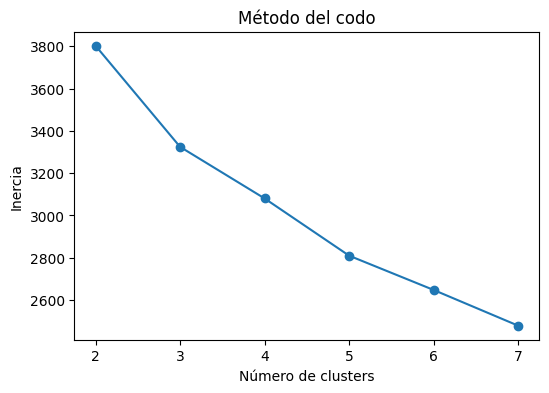

In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,8), inertia, marker='o')
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.show()


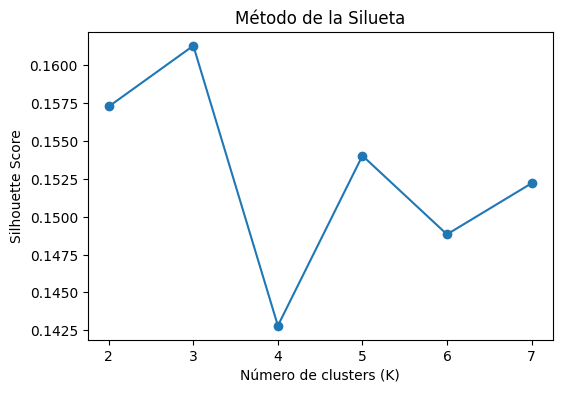

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K = range(2, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)



plt.figure(figsize=(6,4))
plt.plot(K, silhouette_scores, marker='o')
plt.title('Método de la Silueta')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()


In [29]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [30]:
cluster_summary = df.groupby('cluster')[[
    'age_numeric',
    'ctr',
    'lead_rate',
    'application_rate',
    'enrollment_rate',
    'ROI',
]].mean()

cluster_summary


,age_numeric,ctr,lead_rate,application_rate,enrollment_rate,ROI
cluster,,,,,,
0,23.887931,0.067338,0.208490,0.578480,0.524980,41.679686
1,27.774627,0.051166,0.196473,0.542376,0.493982,18.845745
2,19.000000,0.052079,0.198646,0.541786,0.493388,19.363822


### Resultados
* El análisis del método de la silueta indica una estructura de clusters débil (silhouette ≈ 0.16), lo que sugiere que las variables analizadas presentan un comportamiento continuo y no se encuentran claramente separadas en grupos. Por este motivo, la clusterización se interpreta como un análisis exploratorio.

* Los clusters 1 y 2 presentan valores muy similares en términos de CTR, tasas del funnel y ROI, diferenciándose principalmente por la edad promedio. En contraste, el cluster 0 destaca por presentar un CTR significativamente mayor (≈ 1.6 puntos porcentuales), lo que se traduce en un ROI sustancialmente más alto (≈ +22 puntos porcentuales).

* Este resultado sugiere que pequeñas mejoras en el CTR pueden generar impactos desproporcionados en la rentabilidad, abriendo la posibilidad de investigar si este comportamiento corresponde a campañas específicas o a patrones replicables.

# Analisis de clusters

In [31]:
df['is_cluster_0'] = (df['cluster'] == 0).astype(int)

df.groupby('TargetAudience')['is_cluster_0'].mean()


TargetAudience
17–21 Age    0.196203
21–35 Age    0.184783
22–27 Age    0.413043
25–35 Age    0.168000
Name: is_cluster_0, dtype: float64

In [32]:
df.groupby('CampaignName')['is_cluster_0'].mean()

CampaignName
Hackathon                    0.230769
MBA Admission                0.184783
Placements                   0.337748
Semester Exchange Program    0.254902
UG Admission                 0.157609
Name: is_cluster_0, dtype: float64

El análisis muestra que las campañas dirigidas al segmento 22–27 años presentan una probabilidad significativamente mayor de pertenecer al cluster de alto rendimiento. Este resultado sugiere que no es la edad en sí misma el factor determinante, sino la forma en que las campañas son diseñadas y posicionadas para dicho público. Variables como el tipo de campaña refuerzan este patrón.

In [33]:
df.groupby('TargetAudience')['ctr'].describe()


,count,mean,std,min,25%,50%,75%,max
TargetAudience,,,,,,,,
17–21 Age,316.0,0.055115,0.014675,0.030027,0.043500,0.054563,0.068707,0.079933
21–35 Age,184.0,0.055477,0.014157,0.030097,0.044306,0.057231,0.066539,0.079718
22–27 Age,138.0,0.055448,0.015619,0.030257,0.040818,0.055364,0.070035,0.079947
25–35 Age,125.0,0.054475,0.015233,0.030011,0.041785,0.054599,0.067887,0.079784


Aunque el segmento 22–27 presenta una mayor presencia en el cluster de alto rendimiento, el análisis de CTR promedio por audiencia muestra valores muy similares entre segmentos. Esto indica que el comportamiento observado no se explica por la audiencia en sí, sino por una combinación de factores que, en conjunto, conducen a un mejor desempeño

# Machine Learning supervisado

## Modelado predictivo de impresiones

El objetivo de esta sección es construir un modelo que permita estimar la cantidad de impresiones esperadas antes de lanzar una campaña,
utilizando variables conocidas en la etapa de planificación.

In [34]:
import numpy as np

df['month'] = df['Date'].dt.month

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [35]:
featuresML = [
    'Cost (₹)',
    'month_sin',
    'month_cos',
    'age_numeric'
]

In [36]:
X = df[featuresML]
y = df['Impressions']

In [37]:
X_encoded = pd.get_dummies(X, dtype=int,drop_first=True)

## Train / Test

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Lineal regretion

Se comienza con un modelo lineal como línea base y luego se evalúa un modelo no lineal (Random Forest) para capturar relaciones más complejas.

In [39]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, r2

(33458.58924188404, 0.6800189063748692)

## Random forest

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
from sklearn.metrics import mean_absolute_error, r2_score

rf_pred = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)

mae_rf, r2_rf

(30362.282468711768, 0.713629259019172)

### Grid search

In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300],
    'max_depth': [8, 12, 20, None],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt', 0.7]
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [8, 12, ...], 'max_features': ['sqrt', 0.7], 'min_samples_leaf': [3, 5, ...], 'n_estimators': [300]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [44]:
best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

mae, r2


(30872.288520263617, 0.7206820127528736)

# Simulación de escenario real: predicción antes de lanzar una campaña

Esta función simula el comportamiento de un cliente o analista que, antes de invertir presupuesto,
ingresa valores conocidos (costo, mes y audiencia) para obtener una estimación de impresiones esperadas.


In [45]:
import numpy as np

MONTH_MAP = {
    'january': 1, 'february': 2, 'march': 3, 'april': 4,
    'may': 5, 'june': 6, 'july': 7, 'august': 8,
    'september': 9, 'october': 10, 'november': 11, 'december': 12
}

def month_to_cyclical(month_name: str):
    month = MONTH_MAP[month_name.lower()]
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    return month_sin, month_cos


In [46]:
AGE_RANGE_MAP = {
    '17–21': 19,
    '22–27': 24.5,
    '21–35': 28,
    '25–35': 30
}

def age_range_to_numeric(age_range: str):
    if age_range not in AGE_RANGE_MAP:
        raise ValueError(f'Rango inválido. Usa uno de: {list(AGE_RANGE_MAP.keys())}')
    return AGE_RANGE_MAP[age_range]


In [47]:
import pandas as pd

def predict_impressions(
    cost,
    month_name,
    age_range,
    model,
    feature_columns
):
    month_sin, month_cos = month_to_cyclical(month_name)
    age_numeric = age_range_to_numeric(age_range)

    input_df = pd.DataFrame([{
        'Cost (₹)': cost,
        'month_sin': month_sin,
        'month_cos': month_cos,
        'age_numeric': age_numeric
    }])

    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    prediction = model.predict(input_df)[0]
    return round(prediction)


In [48]:
predict_impressions(
    cost=120000,
    month_name='December',
    age_range='22–27',
    model=best_rf,
    feature_columns=X_encoded.columns
)


195083

## Conclusiones

- El análisis exploratorio mostró que un mayor gasto no garantiza un mayor ROI.
- El funnel revela que el principal cuello de botella se encuentra en la captación inicial (CTR).
- El clustering sugiere que pequeñas mejoras en métricas clave pueden generar impactos significativos en la rentabilidad.
- El modelo de Random Forest mejora el desempeño frente a un modelo lineal, capturando relaciones no lineales.
- Finalmente, se construyó una función que permite estimar impresiones antes de lanzar una campaña, aportando valor práctico al proceso de toma de decisiones.
